<a href="https://colab.research.google.com/github/amkorwalid/nanoGPT/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
# One single layer with one single head transformer decoder
class nanoGPT(nn.Module):
    def __init__(self, emb_dim, vocab_size, block_size):
        super().__init__()

        self.emb_dim = emb_dim

        self.token_emb = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(block_size, emb_dim)

        self.query = nn.Linear(in_features=emb_dim, out_features=emb_dim)
        self.key = nn.Linear(in_features=emb_dim, out_features=emb_dim)
        self.value = nn.Linear(in_features=emb_dim, out_features=emb_dim)

        self.ln1 = nn.LayerNorm(emb_dim)
        self.ln2 = nn.LayerNorm(emb_dim)

        self.ffwd = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            nn.ReLU(),
            nn.Linear(4 * emb_dim, emb_dim),
        )

        self.head = nn.Linear(emb_dim, vocab_size)

        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T = x.shape  # B: batch size, T: sequence length

        x = self.token_emb(x) + self.pos_emb(torch.arange(0, T, device=x.device))

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        scores = (Q @ K.transpose(-2, -1)) / (self.emb_dim**0.5)
        mask = torch.tril(torch.ones_like(scores)) == 0
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))

        sa = F.softmax(scores, dim=-1) @ V

        x = self.ln1(x + sa)
        x = self.ln2(x + self.ffwd(x))

        logits = self.head(x)

        return logits


In [8]:
with open("en_dataset.txt", "r", encoding="utf-8") as f:
    data = f.read()

chars = sorted(list(set(data)))
vocab_size = len(chars)

In [9]:
data_enc = {ch: i for i, ch in enumerate(chars)}
data_dec = {i: ch for i, ch in enumerate(chars)}

In [10]:
tokens = [data_enc[c] for c in data]
tokens = torch.tensor(tokens, dtype=torch.long)
tokens.shape

torch.Size([8694761])

In [11]:
epochs = 100000
batch_size = 64
block_size = 128
emb_dim = 64
learning_rate = 1e-3
losses = []

In [12]:
model = nanoGPT(emb_dim, vocab_size, block_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)


In [13]:
# Training Loop
model.train()
for epoch in range(epochs):
    batch_idx = torch.randint(0, len(tokens) - block_size, (batch_size,))
    x = torch.stack([tokens[i:i+block_size] for i in batch_idx]).to(device)
    y = torch.stack([tokens[i+1:i+block_size+1] for i in batch_idx]).to(device)

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # if (epoch+1) % 1000 == 0:
    #     learning_rate /= 2.0

    if (epoch+1) % 1000 == 0:
        print(f'Epoch : {epoch+1} | Loss : {loss.item()}')

Epoch : 1000 | Loss : 1.810297966003418
Epoch : 2000 | Loss : 1.580224871635437
Epoch : 3000 | Loss : 1.5320680141448975
Epoch : 4000 | Loss : 1.5040113925933838
Epoch : 5000 | Loss : 1.4787793159484863
Epoch : 6000 | Loss : 1.450498104095459
Epoch : 7000 | Loss : 1.40693998336792
Epoch : 8000 | Loss : 1.401196002960205
Epoch : 9000 | Loss : 1.3451392650604248
Epoch : 10000 | Loss : 1.3039616346359253
Epoch : 11000 | Loss : 1.3706169128417969
Epoch : 12000 | Loss : 1.3211441040039062
Epoch : 13000 | Loss : 1.2832486629486084
Epoch : 14000 | Loss : 1.3334068059921265
Epoch : 15000 | Loss : 1.318142294883728
Epoch : 16000 | Loss : 1.3015751838684082
Epoch : 17000 | Loss : 1.3304779529571533
Epoch : 18000 | Loss : 1.300523042678833
Epoch : 19000 | Loss : 1.2755787372589111
Epoch : 20000 | Loss : 1.2927701473236084
Epoch : 21000 | Loss : 1.2933861017227173
Epoch : 22000 | Loss : 1.2741830348968506
Epoch : 23000 | Loss : 1.2982311248779297
Epoch : 24000 | Loss : 1.2435905933380127
Epoch : 2

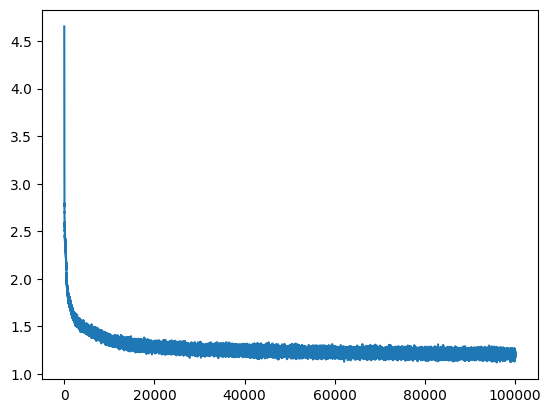

In [14]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.show()

In [24]:
# Generation Loop
# input_token = input('Prompt : ')
input_token = 'I feel'
gen_tokens = block_size - len(input_token)

context = torch.tensor([data_enc[c] for c in input_token], dtype=torch.long).to(device)
context = context.unsqueeze(0)
model.eval()
for token in range(gen_tokens):
    logits = model(context)
    # logits = logits[:, -1, :]
    # probs = F.softmax(logits, dim=-1)
    # next_token = torch.multinomial(probs, num_samples=1)
    next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
    context = torch.cat((context, next_token), dim=1)

print(f'Generated : {"".join([data_dec[i.item()] for i in context[0]])}')

Generated : I feel bear toys and the saw a big back to the ball and said, "I want to the saw a big back to the ball and said, "I was so happ
